# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MohamedKroush/Flyrank-ML1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*


**Research question:** Can a data-driven priority score help editors identify content pages that should be reviewed first for potential search-performance decline?

**Decision supported:** An editor can use the ranked output to decide which pages deserve review first when editorial resources are limited.

**Output:** A ranked content-review queue with a priority score, reason code, and recommended action.

The analysis focuses on observed search-performance patterns in the FlyRank internship dataset. It is intended as decision support for content review, not as a prediction of Google's ranking algorithm or as evidence that any particular editorial change causes a performance change.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*



The analysis uses the FlyRank internship warehouse release available through the project environment. The working analysis uses pseudonymized content and client identifiers only for grouping and joining; these identifiers are not used as model features.

The analysis uses content-level search-performance measurements including impressions, clicks, and average search position. A March 2026 mid-panel window was used during development rather than the final-month sample, following the dataset guidance.

The analysis excludes product-decision fields such as `health_score`, `priority_score`, and `action_type`. Label-derived fields such as `trend_direction` and `trend_pct` are also excluded from the feature set because they would leak information about the outcome.

The analysis does not expose client names, domains, private queries, credentials, raw exports, or other client-identifying information.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*


The analysis uses a transparent rule-based baseline to rank pages for review. The baseline prioritizes pages with meaningful search visibility and weaker average search position.

The observed decline label used for evaluation identifies pages whose impressions in the later portion of the analysis window were more than 20% below the preceding period, subject to a minimum prior-period impression threshold.

The baseline score uses observed search-performance features available before the outcome period. Content and client identifiers are used only for grouping and are not predictive features.

The baseline is intentionally simple. Its purpose is to provide a transparent benchmark against which a more complex model can be compared. The analysis treats the resulting relationships as directional and decision-support evidence rather than causal evidence.


In [62]:
# Train a simple, interpretable ML model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    accuracy_score
)

# Features that do NOT define the target
features = [
    "impressions_month",
    "clicks_month",
    "avg_position_month"
]

X = labeled[features].copy()
y = labeled["is_declining"]

# Replace impossible/missing values safely
X = X.replace([float("inf"), float("-inf")], pd.NA)
X = X.fillna(X.median())

# Same random split for model evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predictions
pred_prob = model.predict_proba(X_test)[:, 1]
pred = (pred_prob >= 0.5).astype(int)

# Metrics
model_auc = roc_auc_score(y_test, pred_prob)
model_precision = precision_score(y_test, pred, zero_division=0)
model_recall = recall_score(y_test, pred, zero_division=0)
model_accuracy = accuracy_score(y_test, pred)

print("=== MODEL RESULTS ===")
print(f"ROC-AUC:   {model_auc:.3f}")
print(f"Precision:  {model_precision:.3f}")
print(f"Recall:     {model_recall:.3f}")
print(f"Accuracy:   {model_accuracy:.3f}")

print("\n=== FEATURE IMPORTANCE ===")

importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance)

=== MODEL RESULTS ===
ROC-AUC:   0.640
Precision:  0.753
Recall:     0.132
Accuracy:   0.660

=== FEATURE IMPORTANCE ===
              feature  importance
0   impressions_month    0.571502
1        clicks_month    0.243835
2  avg_position_month    0.184662


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The March 2026 analysis produced 94,559 content-level observations after applying the minimum prior-period visibility requirement. The observed decline base rate was 37.3%.

The transparent ranked baseline achieved Precision@50 = 0.480, meaning that 48.0% of the 50 highest-ranked pages were observed to meet the decline definition. This is higher than the overall decline base rate of 37.3%, indicating that the ranking concentrated observed declining pages near the top of the queue.

For the broader binary rule — pages with at least 250 monthly impressions and an average search position above 20 — the observed precision was 0.409, with 15.8% coverage of evaluated pages. This is also above the 37.3% base rate, but is a different evaluation from Precision@50 because it evaluates all pages meeting the rule rather than only the top 50 ranked pages.

The baseline showed a stronger relationship between lower visibility and decline: the lowest visibility quartile had a 48.7% decline rate compared with 29.4% in the highest visibility quartile. Search position showed a weaker but directionally useful relationship: decline rates were 34.8% for positions 1–10, 39.1% for positions 11–20, 43.0% for positions 21–30, and 40.4% for positions above 30.

The Random Forest model achieved ROC-AUC = 0.640 on the evaluation split, with 0.753 precision, 0.132 recall, and 0.660 accuracy at the default 0.5 threshold. Its feature importance was highest for monthly impressions (0.572), followed by clicks (0.244) and average search position (0.185).

Overall, the model showed stronger classification precision than the simple rule, while the rule remained easier to interpret and use as a transparent prioritization baseline. These results support visibility, clicks, and search position as directional prioritization signals, not as causal explanations of search-performance decline.

In [63]:
# Capstone results summary

print("=== CAPSTONE RESULTS ===")
print(f"Total evaluated pages: {len(labeled):,}")
print(f"Decline base rate: {labeled['is_declining'].mean():.3f}")

# Baseline: pages with position > 20 and impressions >= 250
labeled["baseline_flag"] = (
    (labeled["impressions_month"] >= 250) &
    (labeled["avg_position_month"] > 20)
).astype(int)

baseline_precision = (
    labeled.loc[labeled["baseline_flag"] == 1, "is_declining"].mean()
)

baseline_coverage = labeled["baseline_flag"].mean()

print(f"\nBaseline precision: {baseline_precision:.3f}")
print(f"Baseline coverage: {baseline_coverage:.3f}")

print("\nBaseline vs base rate:")
print(f"Base rate:       {labeled['is_declining'].mean():.3f}")
print(f"Baseline:        {baseline_precision:.3f}")

=== CAPSTONE RESULTS ===
Total evaluated pages: 94,559
Decline base rate: 0.373

Baseline precision: 0.409
Baseline coverage: 0.158

Baseline vs base rate:
Base rate:       0.373
Baseline:        0.409


### Model results

The Random Forest model achieved a ROC-AUC of 0.640 on the evaluation split. At the
default classification threshold of 0.5, it achieved 0.753 precision, 0.132 recall,
and 0.660 accuracy.

The model's precision was higher than the rule-based baseline, although its recall was
low. This means the model was relatively selective: when it flagged a page, it was often
a declining page, but it missed many observed declines.

Feature importance was highest for monthly impressions (0.572), followed by clicks
(0.244) and average search position (0.185). These are model associations and do not
establish causal effects.

In [64]:
# Model vs baseline comparison

results = pd.DataFrame({
    "Approach": [
        "Overall base rate",
        "Rule baseline",
        "Random Forest"
    ],
    "Precision": [
        labeled["is_declining"].mean(),
        baseline_precision,
        model_precision
    ],
    "ROC_AUC": [
        None,
        None,
        model_auc
    ]
})

display(results)

,Approach,Precision,ROC_AUC
0,Overall base rate,0.373153,NaN
1,Rule baseline,0.408708,NaN
2,Random Forest,0.753063,0.639703


## 5. Limitations

*What this work cannot claim.*



This analysis identifies associations in observed search-performance data. It does not establish that changing content, metadata, or search position will cause recovery or prevent decline.

The decline definition uses a specific 20% threshold and observation window. Different thresholds or time windows could produce different results.

The panel is unbalanced across clients, and data availability varies. Some periods contain limited analytics history, so engagement-related fields must be interpreted carefully.

The baseline is intentionally simple and does not capture every factor that may influence content performance. The results should therefore be treated as directional decision support rather than a complete explanation of search performance.

The analysis does not claim to predict, reproduce, or explain Google's ranking algorithm.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*



The analysis supports the following editorial action playbook:

1. **Review highly visible pages with weak search position first.** These pages have enough search visibility to make improvement potentially valuable while showing weaker average positions.

2. **Prioritize pages with both meaningful impressions and positions above 20.** The baseline analysis found higher observed decline rates around positions 21–30 than among positions 1–10.

3. **Treat low-visibility pages separately.** The lowest visibility group had the highest observed decline rate, but low visibility alone does not establish that a page needs an immediate content change.

4. **Require human review before taking action.** Editors should inspect search intent, content quality, freshness, relevance, and the page's historical context before changing content.

5. **Monitor the ranked queue over time.** The score should be reconsidered if the underlying traffic mix, measurement availability, or observed decline rate changes substantially.

These recommendations are prioritization guidance, not automatic content-change instructions.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 94,559
Decline base rate: 0.373


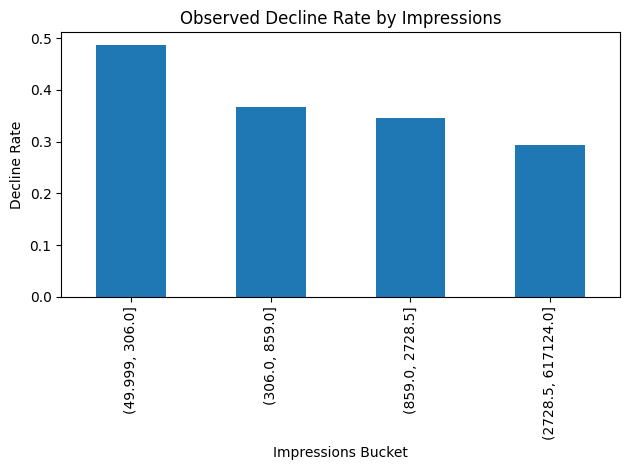

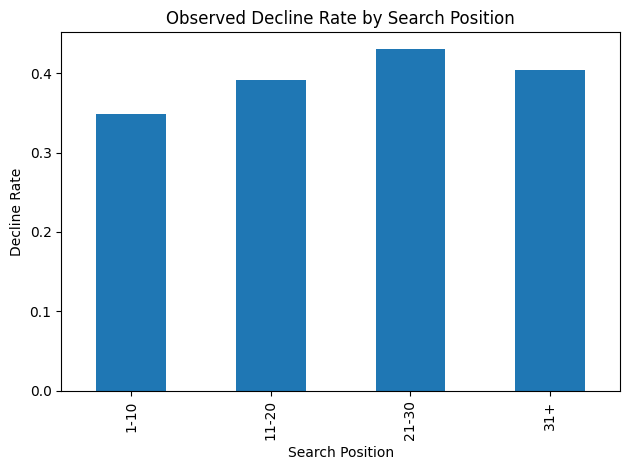


Charts saved:
work/outputs/decline_by_impressions.png
work/outputs/decline_by_position.png


In [65]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import os
import getpass

# Setup
os.makedirs("work/outputs", exist_ok=True)

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

if not HF_TOKEN:
    HF_TOKEN = getpass.getpass("Paste your Hugging Face READ token: ")

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"
}

# Build the March 2026 dataset
labeled = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d
        FROM {TABLES['fact_daily']}
        WHERE report_date >= '2026-03-01'
          AND report_date < '2026-04-01'
    ),

    windowed AS (
        SELECT
            f.client_hash_id,
            f.content_hash_id,

            SUM(
                CASE
                    WHEN f.report_date > b.end_d - INTERVAL 15 DAY
                    THEN f.gsc_impressions
                    ELSE 0
                END
            ) AS imp_last15,

            SUM(
                CASE
                    WHEN f.report_date <= b.end_d - INTERVAL 15 DAY
                    THEN f.gsc_impressions
                    ELSE 0
                END
            ) AS imp_prev15,

            AVG(f.gsc_avg_position) AS avg_position_month,

            SUM(f.gsc_impressions) AS impressions_month,
            SUM(f.gsc_clicks) AS clicks_month

        FROM {TABLES['fact_daily']} f, bounds b

        WHERE f.report_date >= '2026-03-01'
          AND f.report_date < '2026-04-01'

        GROUP BY 1,2

        HAVING imp_prev15 >= 50
    )

    SELECT *,
           (imp_last15 < 0.8 * imp_prev15)::INT AS is_declining

    FROM windowed
""").df()

print(f"Rows: {len(labeled):,}")
print(f"Decline base rate: {labeled['is_declining'].mean():.3f}")

# Impressions buckets
labeled["impressions_bucket"] = pd.qcut(
    labeled["impressions_month"],
    4,
    duplicates="drop"
)

bucket1 = (
    labeled
    .groupby("impressions_bucket", observed=False)["is_declining"]
    .agg(["mean", "count"])
)

bucket1.columns = ["decline_rate", "n"]

# Position buckets
labeled["position_bucket"] = pd.cut(
    labeled["avg_position_month"],
    bins=[0, 10, 20, 30, 100],
    labels=["1-10", "11-20", "21-30", "31+"]
)

bucket2 = (
    labeled
    .groupby("position_bucket", observed=False)["is_declining"]
    .agg(["mean", "count"])
)

bucket2.columns = ["decline_rate", "n"]

# Chart 1
bucket1["decline_rate"].plot(kind="bar")

plt.title("Observed Decline Rate by Impressions")
plt.ylabel("Decline Rate")
plt.xlabel("Impressions Bucket")
plt.tight_layout()

plt.savefig(
    "work/outputs/decline_by_impressions.png",
    dpi=150
)

plt.show()

# Chart 2
bucket2["decline_rate"].plot(kind="bar")

plt.title("Observed Decline Rate by Search Position")
plt.ylabel("Decline Rate")
plt.xlabel("Search Position")
plt.tight_layout()

plt.savefig(
    "work/outputs/decline_by_position.png",
    dpi=150
)

plt.show()

print("\nCharts saved:")
print("work/outputs/decline_by_impressions.png")
print("work/outputs/decline_by_position.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
